<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 3.1: Neural Networks</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Introduction to Neural Networks**

Like many innovations in the technology space, many of it owes their inspiration to biology. For example, the Artificial Neurons used to build Neural Networks are inspired by the human biological neuron within our brains.

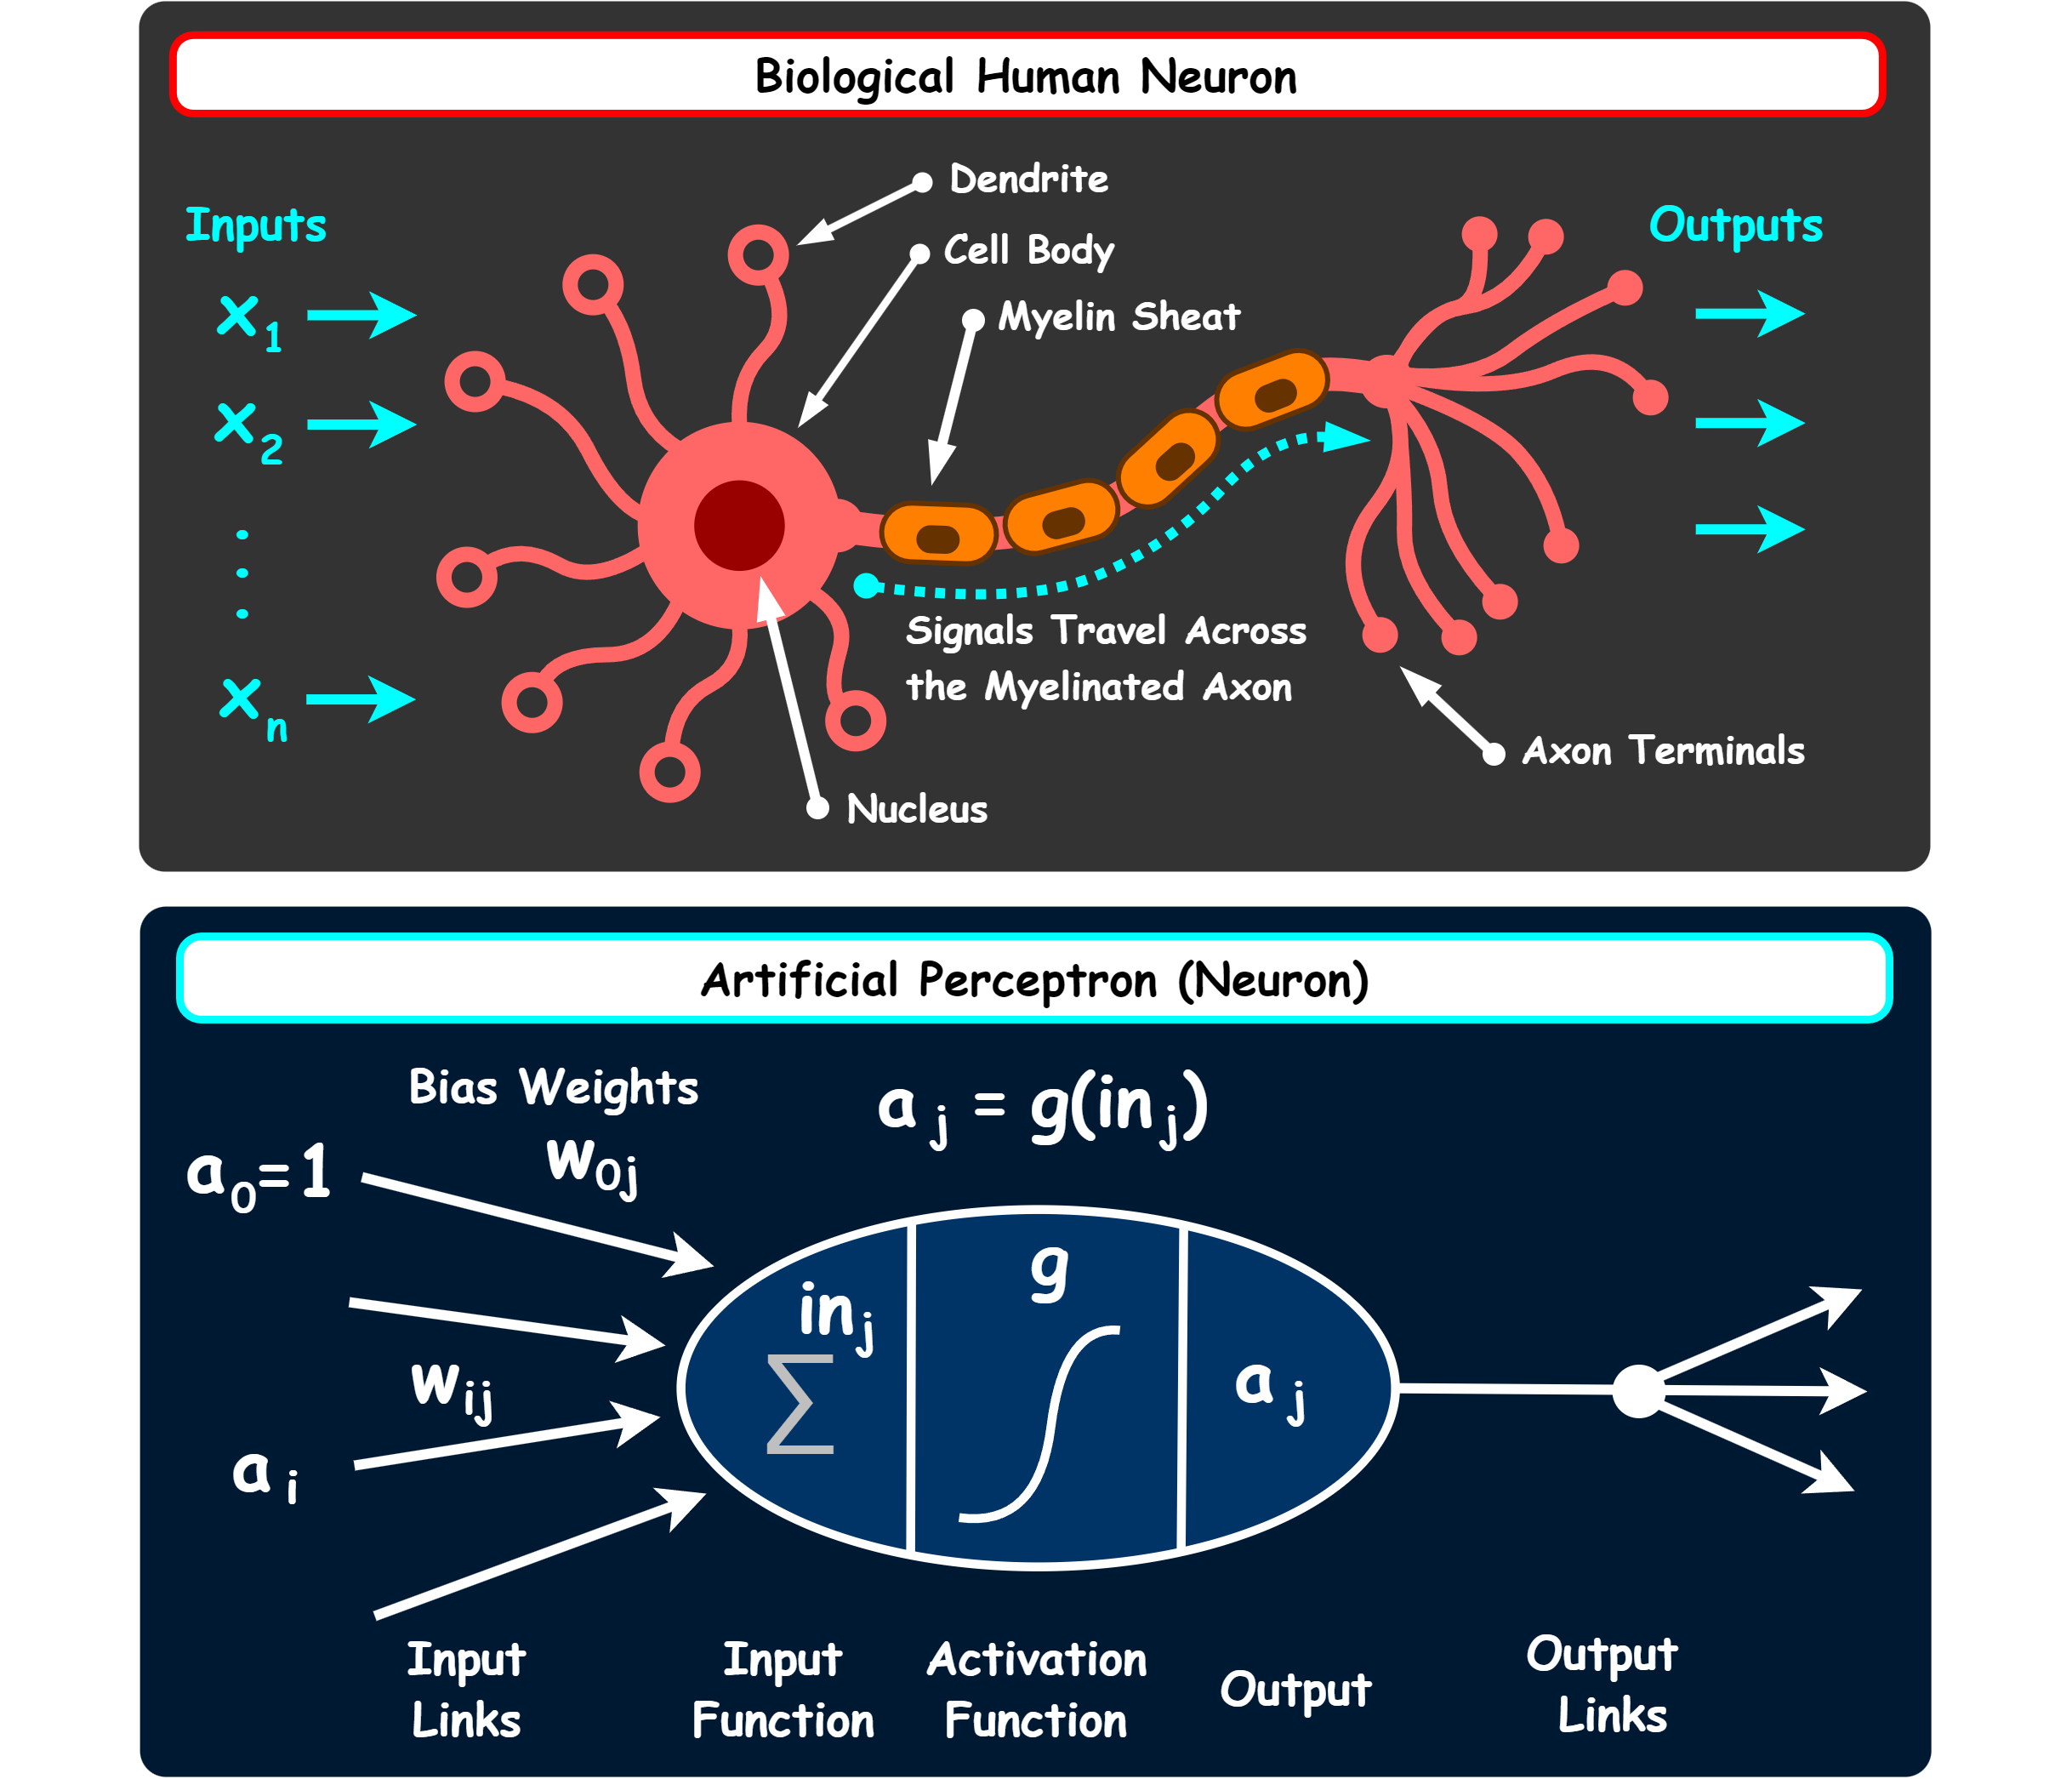

<br>

### **Feed-Forward Neural Networks**

A feed-forward network's goal is to approximate some ideal function $f^*$. In a classification task, for instance, the ideal function $f^*(x)$ maps an input $x$ to a category $y$. The network achieves this by defining a mapping $y = f(x;\theta)$, where $\theta$ are the learnable parameters (weights and biases) that get optimized during training to produce the **best possible approximation** of $f^*$.

These models are called *feed-forward* because information flows in **one direction only**, starting from the input $x$, passing through a series of intermediate computations, and finally arriving at the output $y$. Unlike other architectures, there are no loops or feedback connections; data always moves strictly forward through the network.

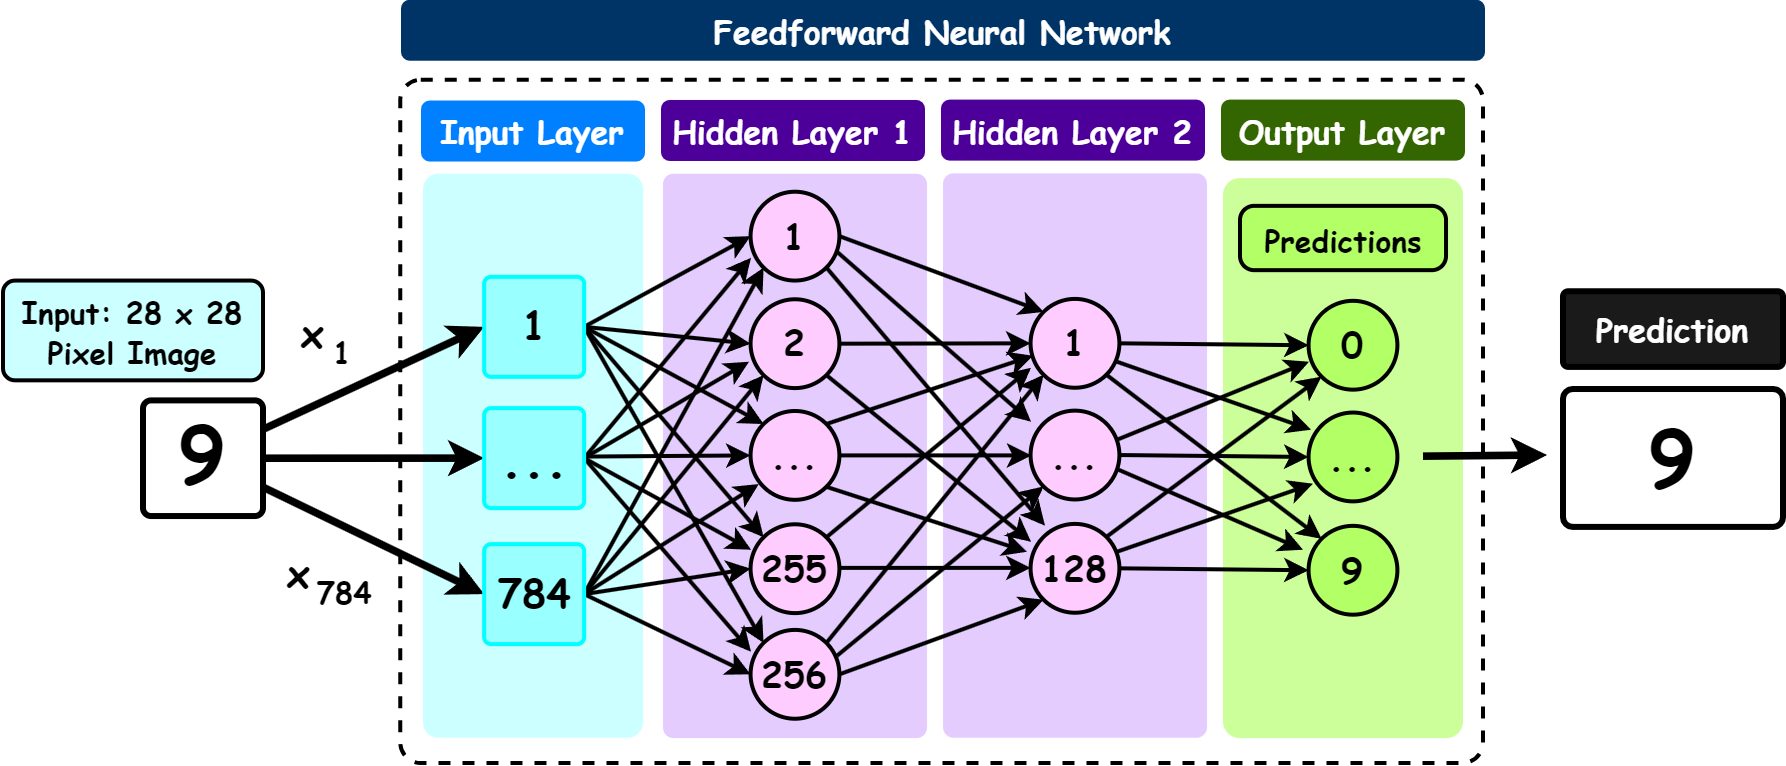

<br>

### **Activation Function**

Activation functions are mathematical functions applied to the output of each neuron in a neural network. They determine whether a neuron should "fire" or not — essentially controlling how much signal gets passed forward through the network.

Without activation functions, no matter how many layers you stack, the network would only be capable of linear transformations, limiting it to solving simple linear problems. Activation functions introduce **non-linearity**, allowing the network to learn complex patterns in data.

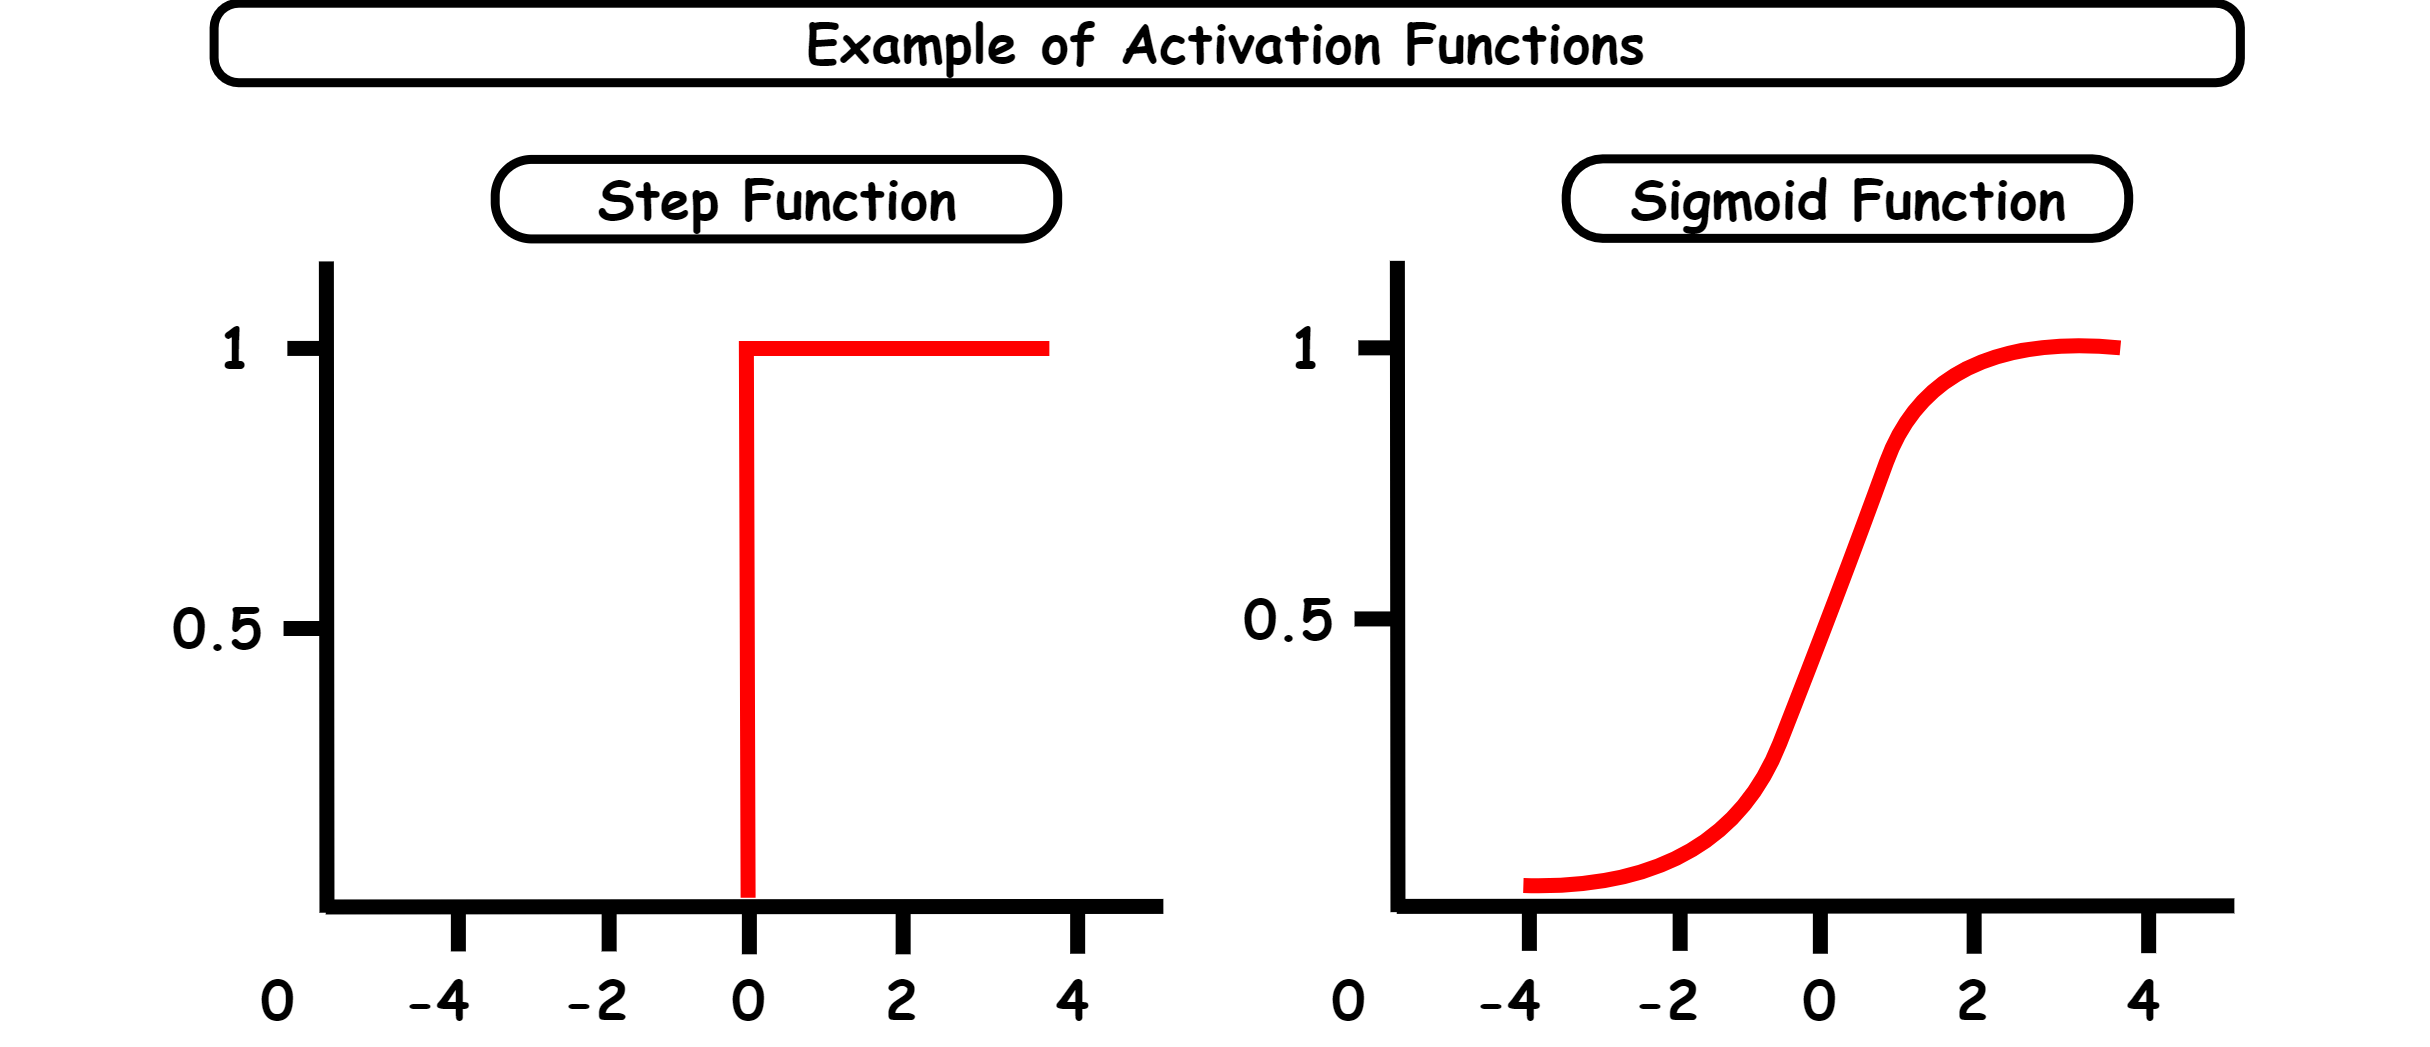

Some common activation functions include:

- **Sigmoid** — squashes output between $0$ and $1$, useful for probability-based outputs
- **ReLU (Rectified Linear Unit)** — outputs $0$ for negative values, and the value itself for positive values. It is the most widely used activation function today
- **Tanh** — similar to Sigmoid but squashes output between $-1$ and $1$

<br>

### **Single Layer Perceptron (Simplest Feedforward Neural Network)**

The simplest form of a feedforward neural network is the **single layer perceptron**. In this model, a set of inputs are each multiplied by their corresponding weights and summed together to produce a single weighted sum. This result is then passed through a threshold function, if the sum exceeds a set threshold (typically zero), the network outputs $1$; otherwise, it outputs $-1$.

Despite its simplicity, the single layer perceptron is a foundational model in deep learning and serves as an important building block for understanding feedforward networks. It is most commonly applied to **binary classification tasks**, where the goal is to separate data into one of two categories.

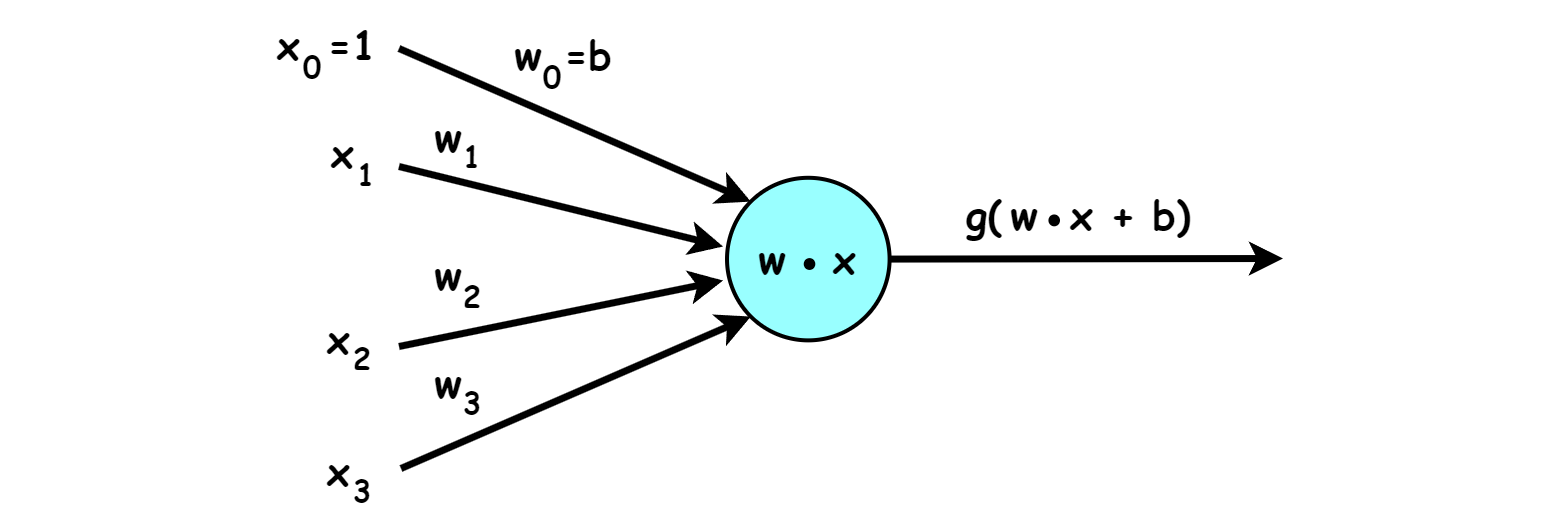

A feedforward neural network with even a single hidden layer containing a sufficient number of neurons can theoretically **represent any continuous function**, given enough neurons and training data. This is known as the *universal approximation theorem*.

Each neuron in the network follows the same fundamental computation:

1. Takes a **weighted sum** of its inputs
2. Adds a **bias term**
3. Applies an **activation function** to introduce non-linearity into the model

---

### **Bias Term & Updated Score**

The score formula can include a **bias term** $b$, which acts as a baseline offset independent of any feature. Think of bias like a default assumption, even before looking at any features, the model starts with a prior lean in one direction. This lets the model shift its decision boundary.

$$Z = \mathbf{w} \cdot \varphi(x) + b = \sum_{j=1}^{k} w_j \varphi_j(x) + b$$

**Step by step with our example** (using $b = 0.1$):

$$Z = (2.5 \times 3) + (-5.0 \times 2) + (-1.2 \times 1) + (0.5 \times 3) + (2.0 \times 0) + (0.7 \times 4.19) + 0.1$$
$$= 7.5 - 10.0 - 1.2 + 1.5 + 0 + 2.933 + 0.1$$
$$= 0.833$$

<br>

### **From Score to Probability — The Sigmoid Function**

The raw score $Z$ is not a probability, it can be any real number. To convert it into something meaningful (a value between 0 and 1), we pass it through the **sigmoid** (logistic) function. Think of sigmoid as a "squasher" — no matter how extreme the score is, it always returns a tidy number between 0 and 1:

$$y = \sigma(Z) = \frac{1}{1 + e^{-z}}$$

This squashes any score into the range $[0, 1]$, which we can interpret as a
probability. The full logistic regression model is then:

$$P(y = 1) = \sigma(\mathbf{w} \cdot \varphi(x) + b) = \frac{1}{1 + e^{-(\mathbf{w} \cdot \varphi(x) + b)}}$$

And since there are only two outcomes:

$$P(y = 0) = 1 - P(y = 1)$$

#### **Example of Applying sigmoid to our score:**

$$P(y = 1) = \frac{1}{1 + e^{-(0.833)}} \approx 0.7$$

$$P(y = 0) = 1 - 0.7 = 0.3$$

The model predicts a **70% chance** the review is positive, and a **30% chance** it is negative.

<br>

### **Loss Function and Cross-Entropy**

**Goal:** find the parameters $\mathbf{w}$ and $b$ that maximise the probability of predicting the correct label $y$ given input $x$. In short, the loss function is how the model measures its own mistakes — a higher loss means the model's prediction was far off from the truth.

With only two possible outcomes (0 or 1), the probability of the correct label from our classifier can be written compactly as:

$$p(y|x) = \hat{y}^{y}(1 - \hat{y})^{1-y}$$

Where $\hat{y} = \sigma(\mathbf{w} \cdot \varphi(x) + b)$ is the model's output. Notice that this is just the **Bernoulli distribution**, when $y = 1$ it simplifies to $\hat{y}$, and when $y = 0$ it simplifies to $1 - \hat{y}$.

#### **Taking the log**

We maximise the log probability instead — the log is monotonic, so whatever parameters maximise $\log p(y|x)$ will also maximise $p(y|x)$. Using log also turns multiplications into additions, making the math far more tractable. This is mathematically easier to work with:

$$\log p(y|x) = \log\left[\hat{y}^{y}(1-\hat{y})^{1-y}\right] = y\log\hat{y} + (1-y)\log(1-\hat{y})$$

#### **Turning it into a loss**

We flip the sign to convert from something to *maximise* into something to *minimise*. This gives us the **cross-entropy loss**:

$$L_{CE}(\hat{y}, y) = -\log p(y|x) = -\left[y\log\hat{y} + (1-y)\log(1-\hat{y})\right]$$

#### **Partial derivatives** (used during gradient descent):

$$\frac{\partial L_{CE}(\hat{y}, y)}{\partial w_j} = [\sigma(\mathbf{w} \cdot \varphi(x) + b) - y]\,\varphi_j(x)$$

$$\frac{\partial L_{CE}(\hat{y}, y)}{\partial b} = \sigma(\mathbf{w} \cdot \varphi(x) + b) - y$$

---

<br>

### **From Logistic Regression to a Neural Classifier**

#### **Logistic Regression as a graph**

We can draw logistic regression visually: each feature $\varphi(x)_j$ is an input node, all connected by weights $\mathbf{w}$ to a single output node that computes the score, which is then passed through sigmoid. This graph view makes it easy to see how information flows from raw features all the way to a final prediction:

$$\text{score} = \mathbf{w} \cdot \varphi(x) \qquad y = \sigma(\text{score}) = \frac{1}{1 + e^{-\text{score}}}$$

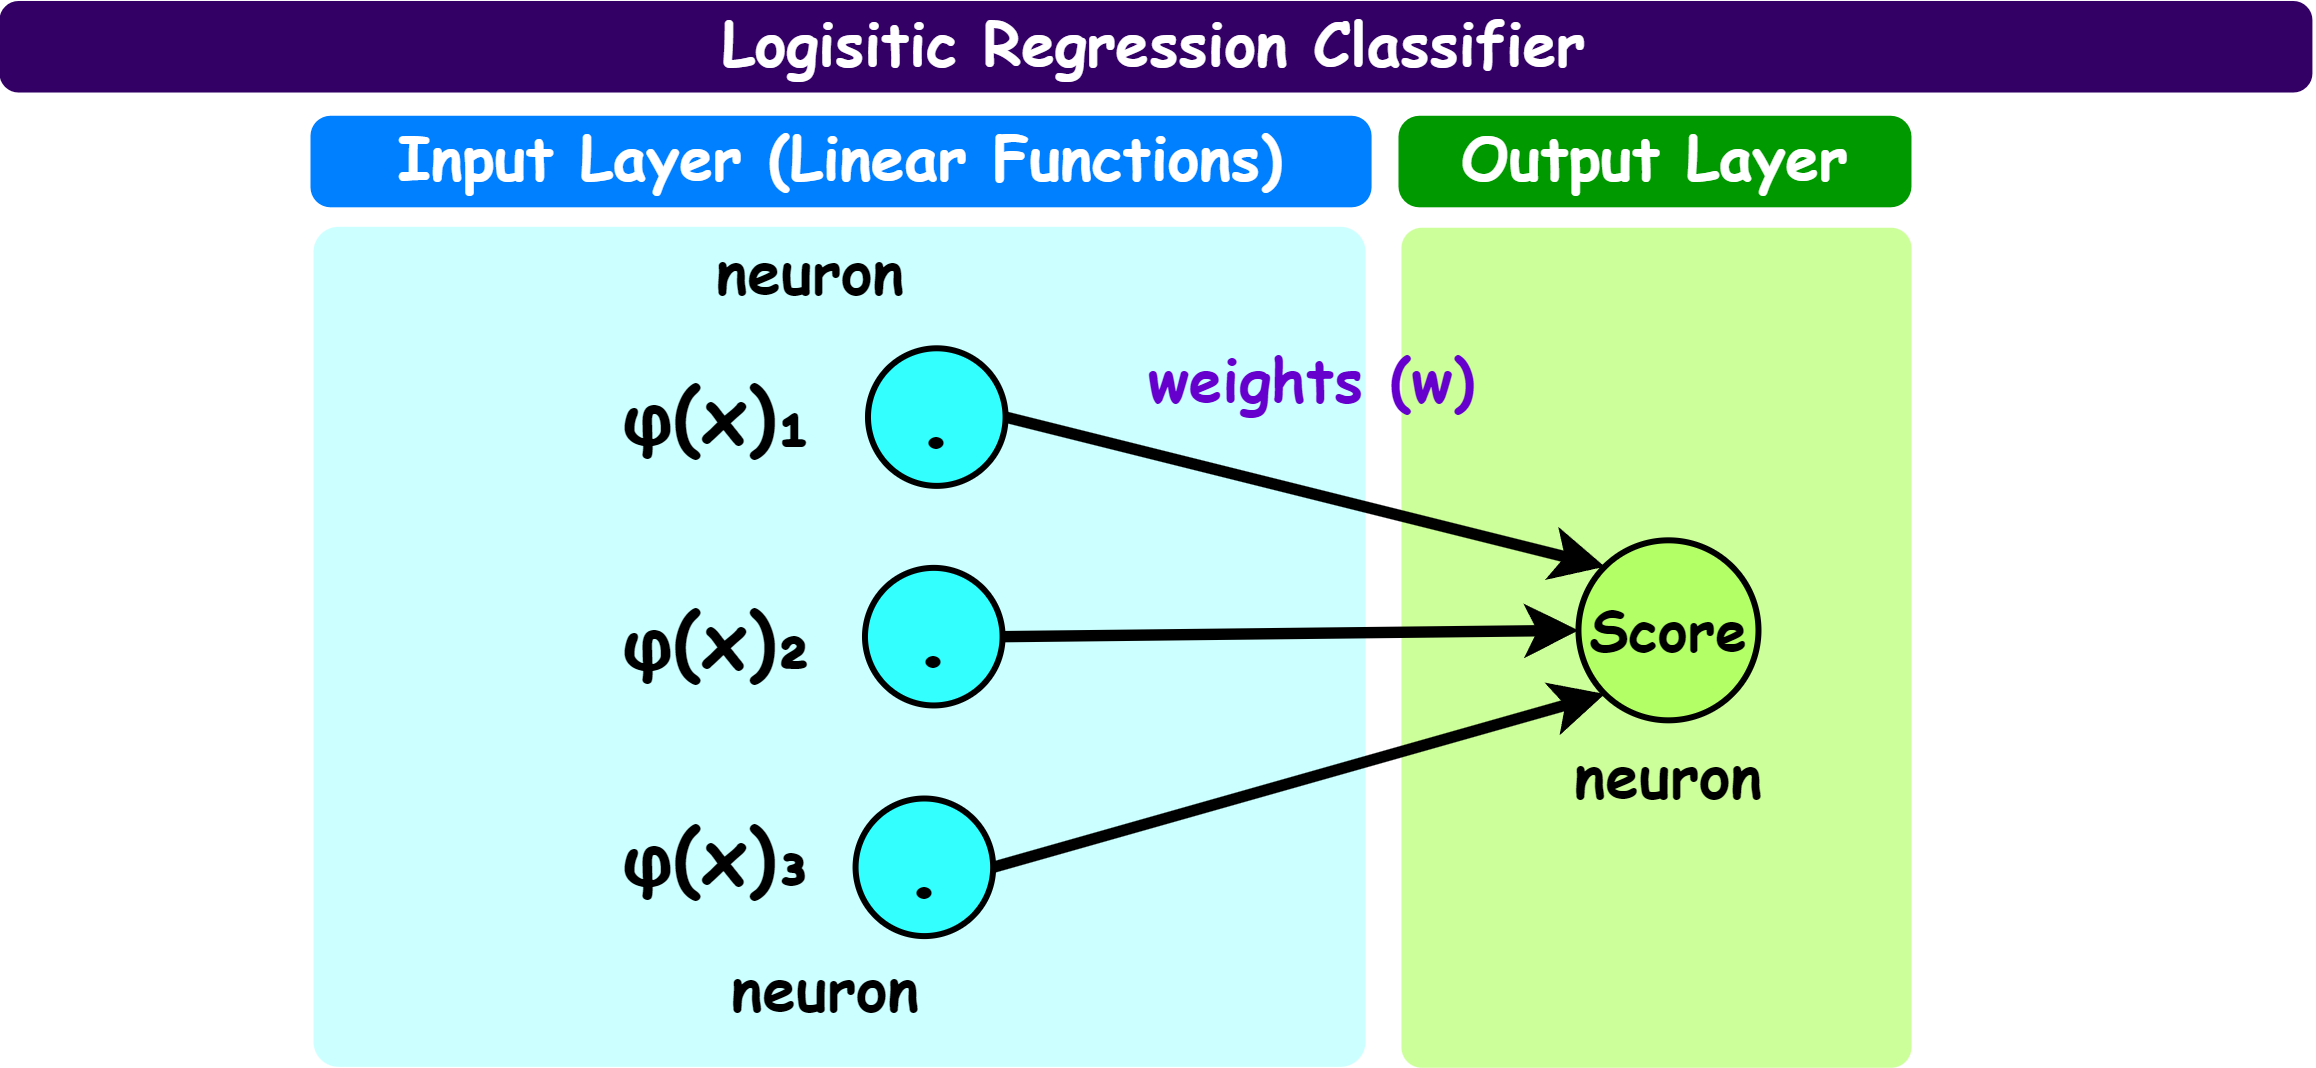

<br>

#### **Adding a hidden layer: Neural Binary Classifier**

A neural network extends this by inserting one or more **hidden layers** between the inputs and the output. The hidden layer is where the network learns abstract, intermediate patterns that raw features alone cannot capture. Each hidden unit $h_j$ applies its own set of weights $\mathbf{v}_j$ and a sigmoid activation:

$$h_j = \sigma(\mathbf{v}_j \cdot \varphi(x)) \qquad \sigma(z) = (1 + e^{-z})^{-1}$$

The output score is then computed from the hidden layer vector $\mathbf{h}$:

$$\text{score} = \mathbf{w} \cdot \mathbf{h} \qquad y = \sigma(\text{score}) = \frac{1}{1 + e^{-\text{score}}}$$

The key difference: instead of computing a score directly from hand-crafted features, the network **learns its own intermediate representations** in the hidden layer. The weights $\mathbf{V}$ (input → hidden) and $\mathbf{w}$ (hidden → output) are all learned from data.

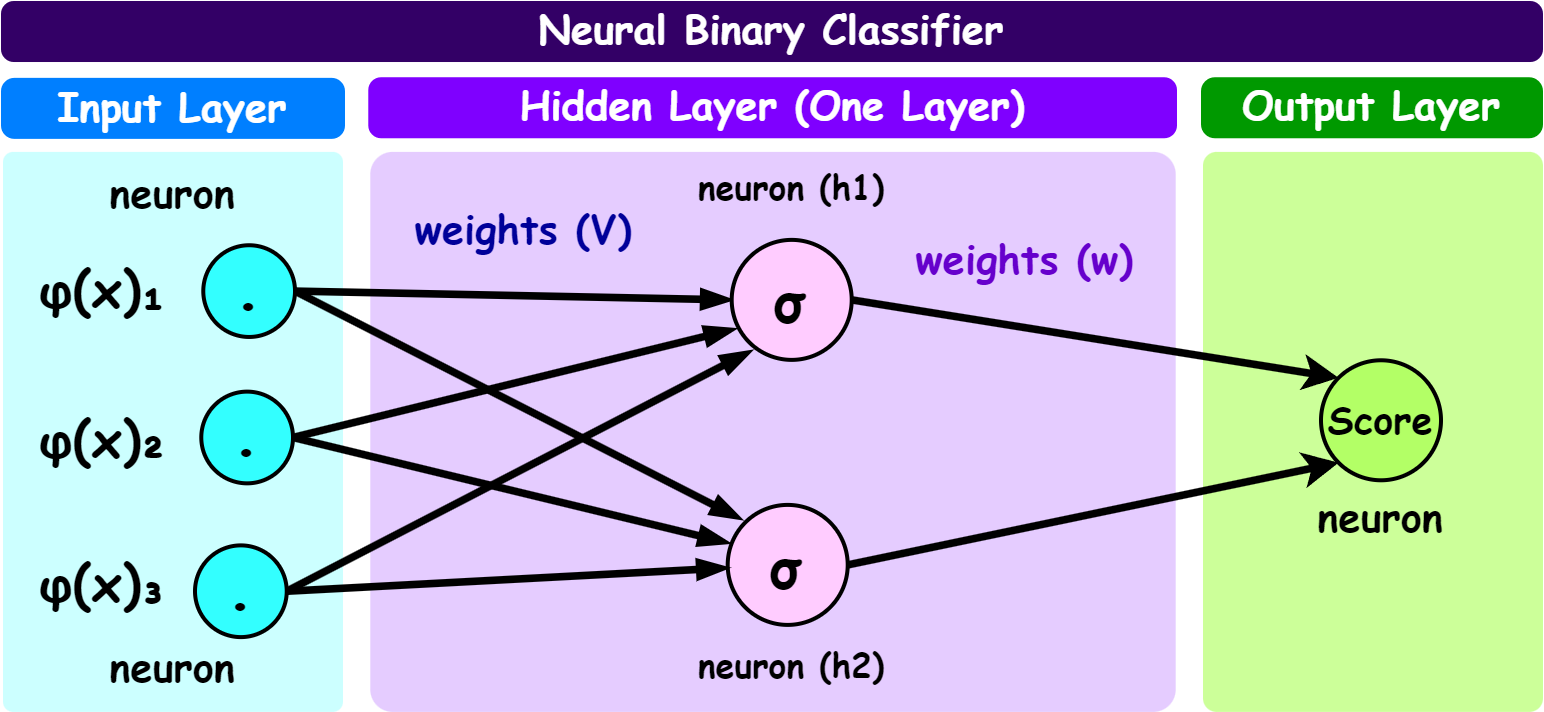

<br>

#### **Diagram Illustrating a Multi-Layer Neural Newtwork with Weights and Bias**

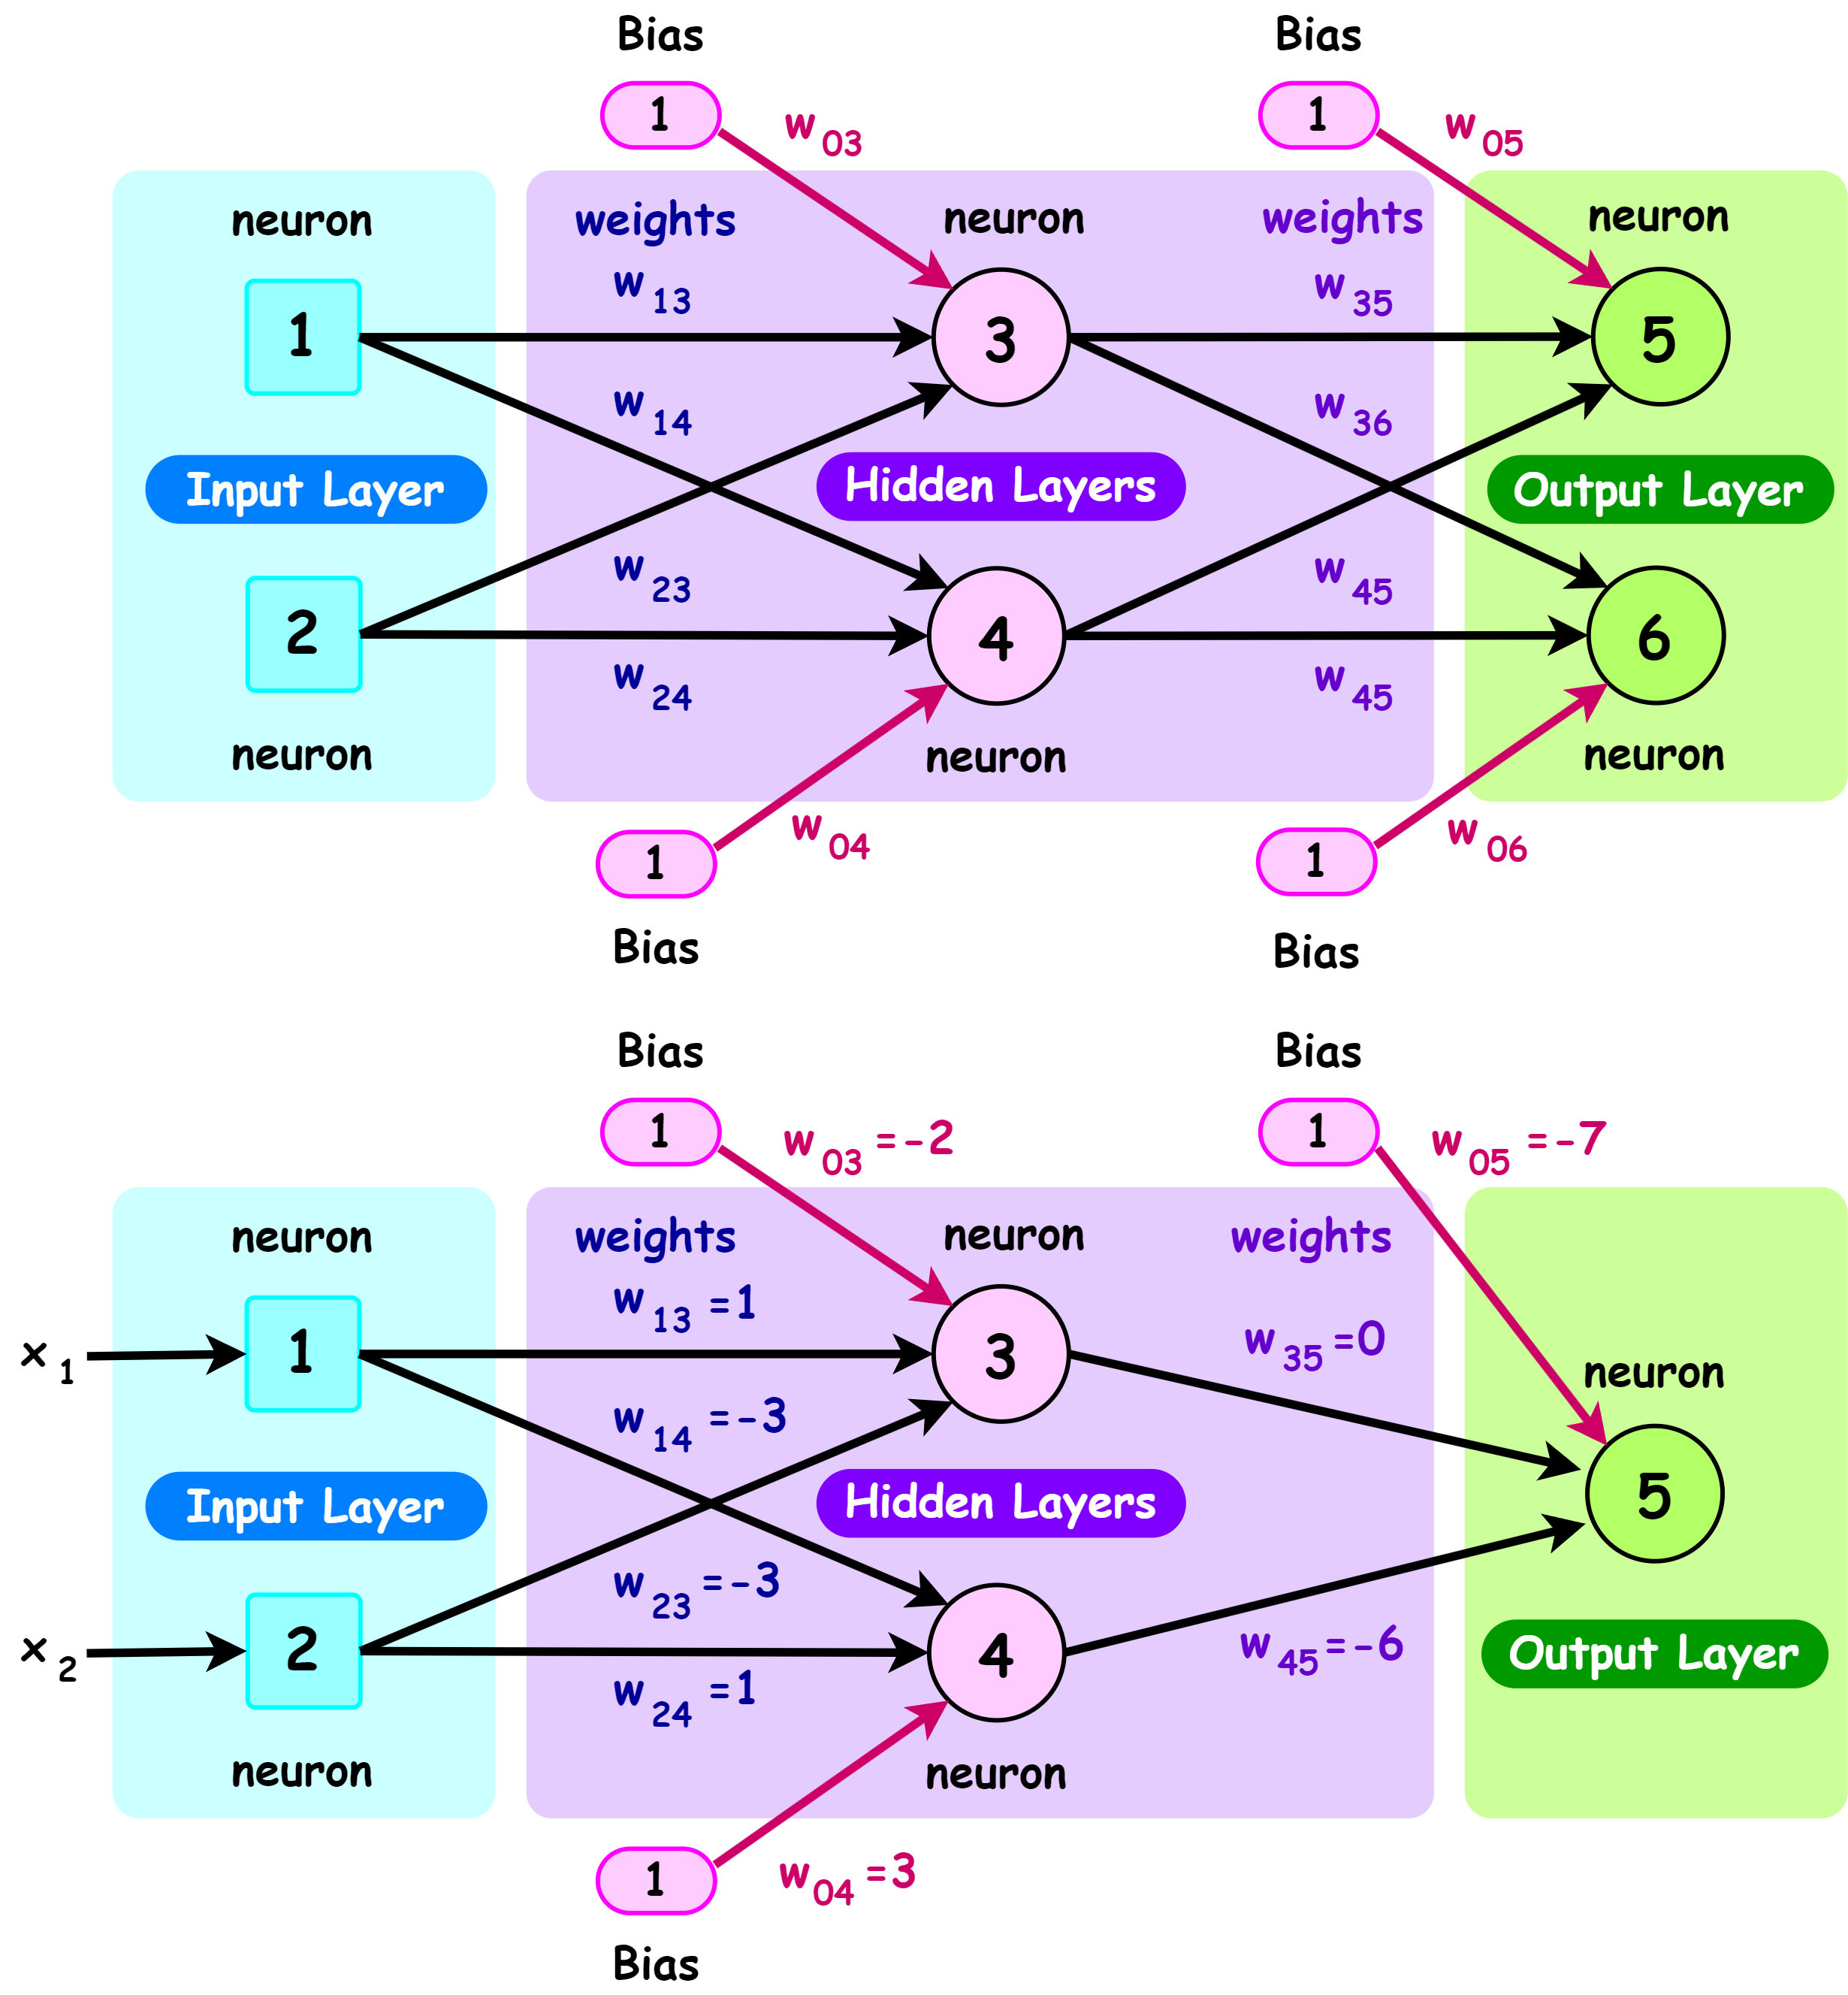

<br>

### **Extending to Multiple Classes — Softmax**

#### **Binary case** ($K = 2$)

When there are only two classes, the output is a single scalar $z$ passed through sigmoid. This works because with only two outcomes, knowing the probability of one immediately tells you the probability of the other:

$$y_1 = \sigma(\mathbf{z}) = \frac{1}{1 + e^{-z}} \qquad y_2 = 1 - y_1$$

#### **Multiclass case** ($K \geq 2$)

When there are $K$ classes, the model outputs a **vector** of $K$ scores $\vec{z}$. Softmax is the generalisation of sigmoid to multiple classes,  instead of splitting probability between two outcomes, it spreads it across all $K$ classes at once. We convert this into a probability distribution using the **softmax** function:

$$y_k = \text{softmax}(\vec{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Softmax ensures all output values are positive and sum to 1, making them valid probabilities. Note that for $K = 2$, softmax reduces to the sigmoid function.

---

### **Training Neural Networks**

**Goal:** find the parameters $\mathbf{V}$ (hidden layer weights) and $\mathbf{w}$ (outputweights) that minimise the total loss across all training examples. This is the same idea as logistic regression — the only difference is that we now have two sets of weights to optimise instead of one.

#### **The Optimization Problem**

$$\min_{\mathbf{V}, \mathbf{w}} \text{ TrainLoss}(\mathbf{V}, \mathbf{w})$$

The training loss is just the average loss over every example in the training
dataset $\mathcal{D}_{\text{train}}$:

$$\text{TrainLoss}(\mathbf{V}, \mathbf{w}) = \frac{1}{|\mathcal{D}_{\text{train}}|} \sum_{(x,y) \in \mathcal{D}_{\text{train}}} \text{Loss}(x, y, \mathbf{V}, \mathbf{w})$$

Where the loss for each individual example is the familiar cross-entropy loss
from Section 6 — the negative log probability of the correct label:

$$\text{Loss}(x, y, \mathbf{V}, \mathbf{w}) = -\log P(y|x)$$

To minimise this, we need to compute the gradient with respect to both weight
matrices — this tells us which direction to nudge each parameter to reduce the
loss:

$$\nabla_{\mathbf{V}, \mathbf{w}} \text{ TrainLoss}(\mathbf{V}, \mathbf{w})$$

Computing this gradient requires grinding through the **chain rule** across every
layer of the network — which is exactly what backpropagation automates.

<br>

### **Computation Graph: Forward & Backward Pass**

A **computation graph** is a way of visualising every mathematical operation inthe network as a tree of nodes, making it easy to see how gradients flow backwards through the model. Frameworks like PyTorch, Keras, and TensorFlow build these graphs automatically so you never have to derive gradients by hand.

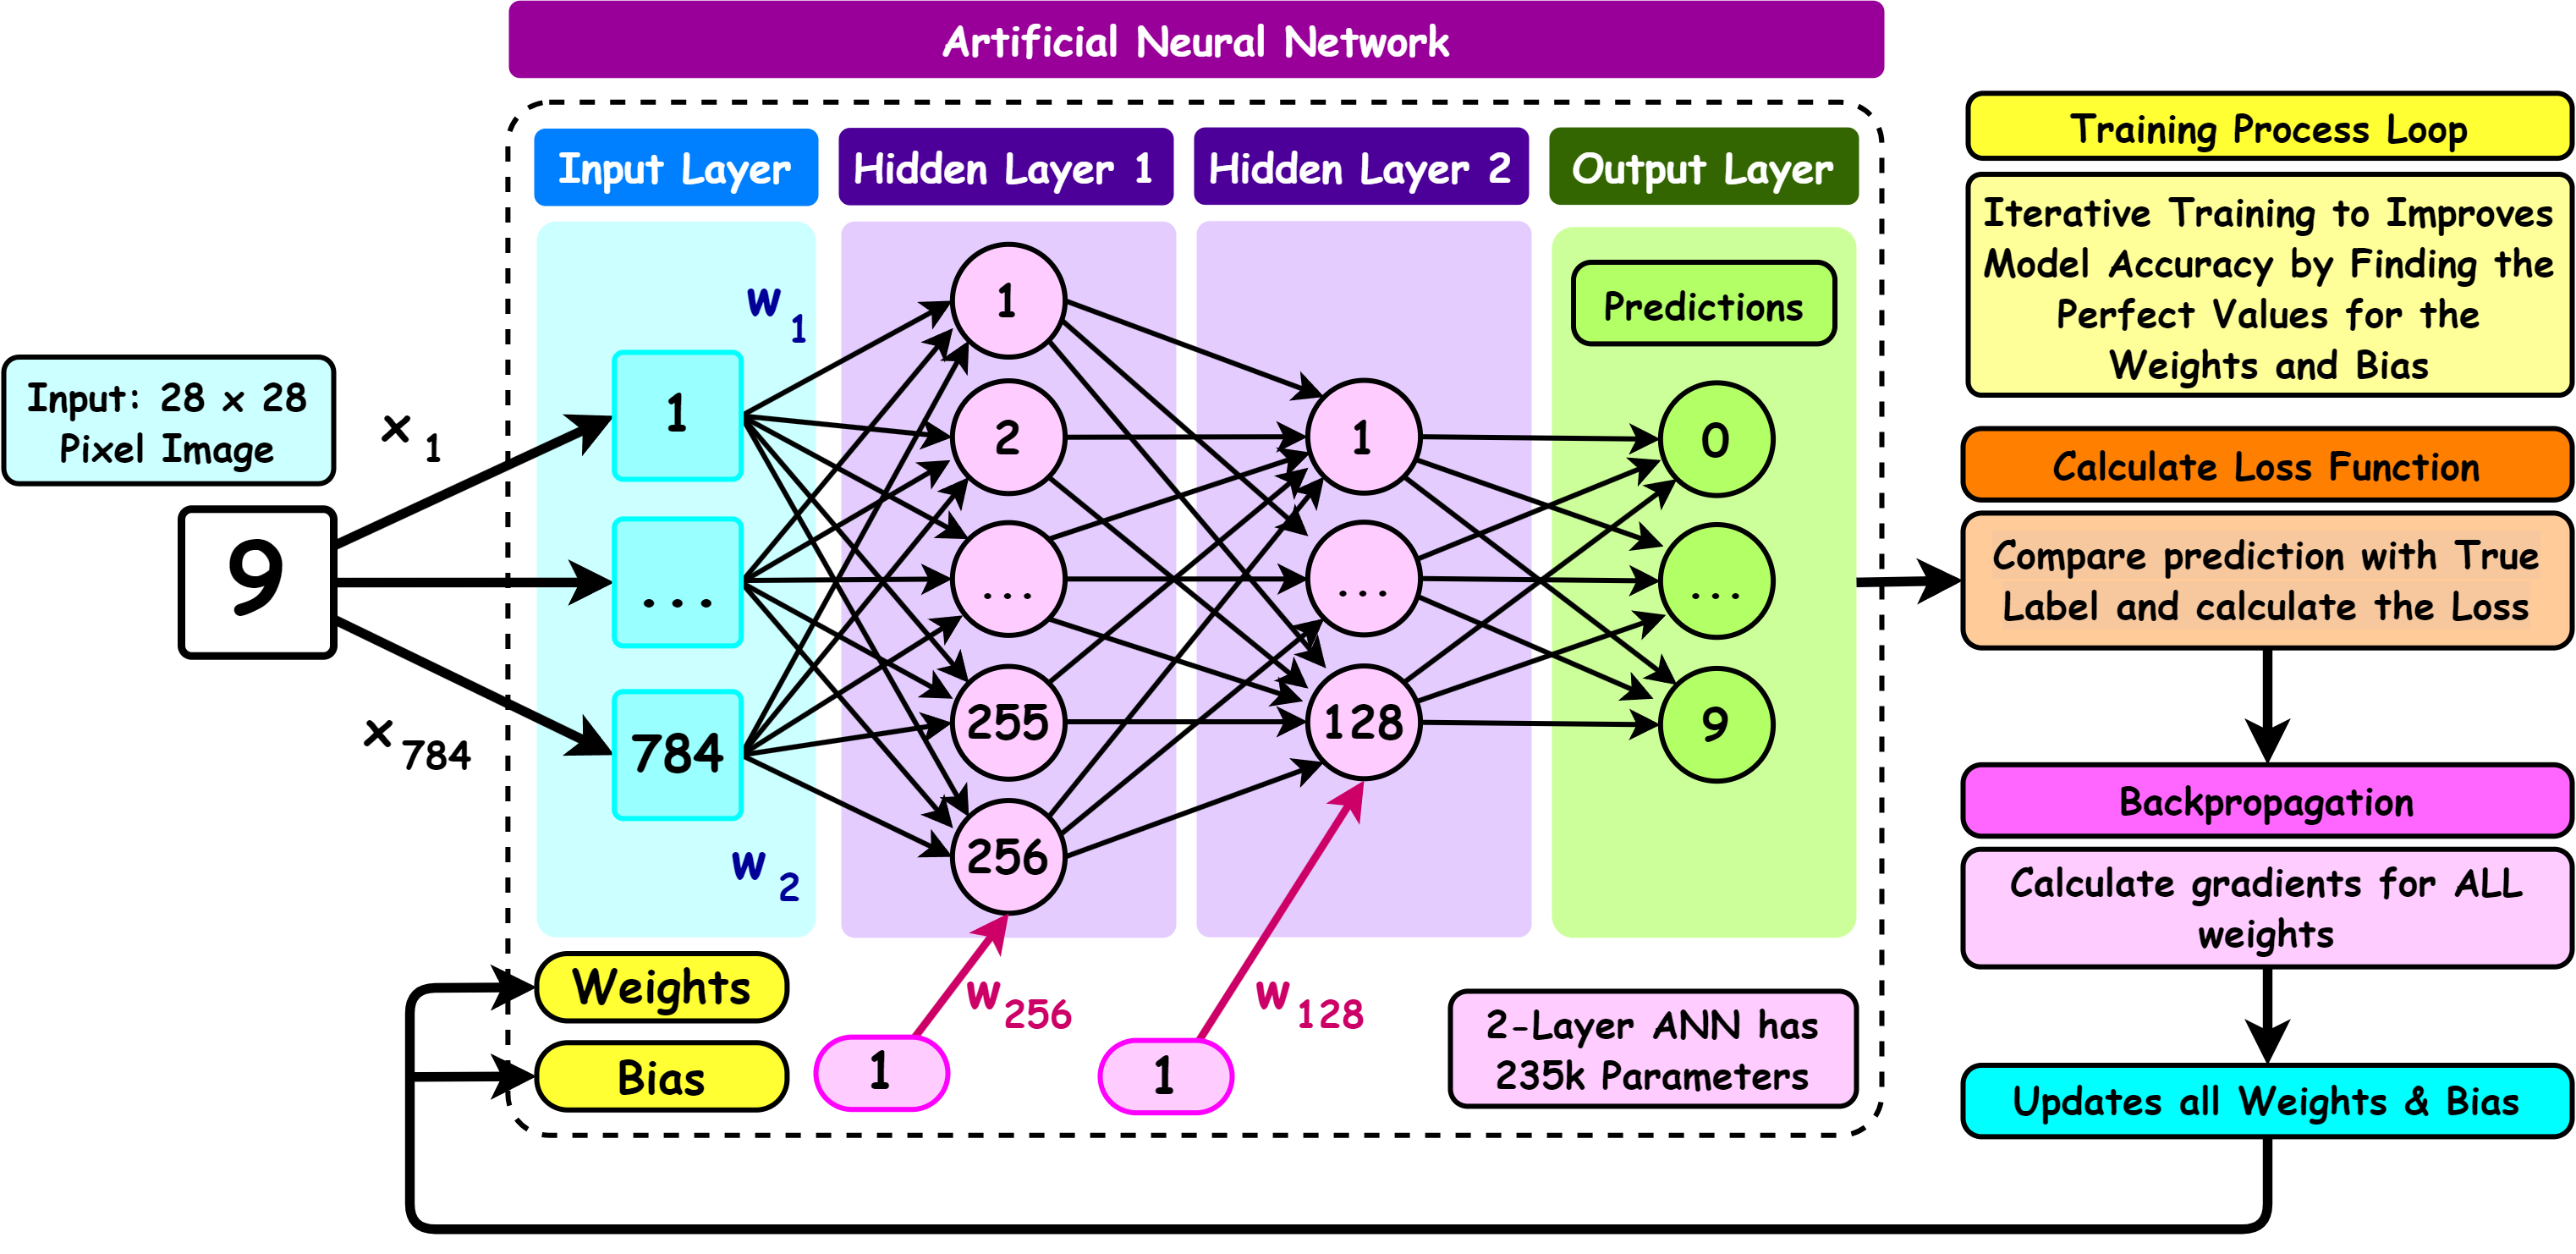

For example, consider a simplified squared loss:

$$\text{Loss}(x, y, \mathbf{w}) = \left(\sum_{j=1}^{k} w_j \sigma(\mathbf{v}_j \cdot \varphi(x)) - y\right)^2$$

This can be drawn as a tree where the leaves are the raw inputs ($\mathbf{v}_1$, $\varphi(x)$, $\mathbf{v}_2$, etc.) and the root is the final loss value.

#### **Forward Pass**

The forward pass computes the value of every node from the **bottom up**, starting at the input leaves and working up to the loss at the root. Each node $f_i$ takes the output of its children and applies its operation (multiply, sigmoid, add, square, etc.):

$$f_i \rightarrow f_j \rightarrow \cdots \rightarrow \text{out}$$

Think of the forward pass as simply running the network to get a prediction and a loss value.

#### **Backward Pass (Backpropagation)**

The backward pass computes the gradient of every node from the **top down**, starting at the root and working back down to the leaves. Each node $g_i$ stores the gradient of the final loss with respect to that node's value, calculated using the chain rule:

$$g_i = \frac{\partial f_j}{\partial f_i} g_j$$

Where $g_j$ is the gradient already computed at the parent node. This is backpropagation, the gradients flow backwards through the same graph that the forward pass flowed through, accumulating along the way.

| Pass | Direction | Computes |
|---|---|---|
| Forward | Leaves → Root | Predictions and loss values $f_i$ |
| Backward | Root → Leaves | Gradients for each node $g_i$ |

<br>

### **Note on Optimization: Convex vs Non-Convex**

Once we have the gradients, we update the weights using gradient descent. In practice, more advanced optimizers like **Adam** are used because they adapt the learning rate automatically and converge much faster than plain gradient descent.

However, optimizing neural networks is fundamentally **harder** than optimizing logistic regression because of the shape of the loss landscape:

| Model | Loss Landscape | Implication |
|---|---|---|
| Linear / Logistic Regression | **Convex** — one smooth bowl shape | Gradient descent always finds the global minimum |
| Neural Networks | **Non-convex** — many hills and valleys | Gradient descent can get stuck in local minima |

This is why training neural networks requires careful choices of learning rate, optimizer, and initialisation — there is no guarantee of finding the perfect solution, only a good enough one.

<br>

### **End-to-End Feature Learning**

Recall that up to now, the feature vector $\varphi(x)$ was hand-crafted, we manually decided what to measure (positive word count, presence of "no", etc.). But what if we let the network learn its own features automatically?

**End-to-end learning** does exactly this — instead of fixing $\varphi(x)$ as a hand-crafted input, we treat the input representations themselves as parameters to be learned during training alongside $\mathbf{V}$ and $\mathbf{w}$. An additional weight matrix $\mathbf{U}$ is added to learn the input representations directly from raw data.

$$\varphi(x)_1, \varphi(x)_2, \varphi(x)_3 \xrightarrow{\mathbf{U}} \xrightarrow{\mathbf{V}, \sigma} h_1, h_2 \xrightarrow{\mathbf{w}} \text{score}$$

**The tradeoff:**

| | Hand-crafted Features | End-to-End Learning |
|---|---|---|
| Feature design | Manual, requires domain knowledge | Automatic, learned from data |
| Interpretability | High — you know what each feature means | Low — features are abstract |
| Flexibility | Limited to what you think to measure | Can discover patterns you wouldn't think of |
| Data needed | Works with less data | Usually needs more data |

The power of end-to-end learning is that the network can discover useful patterns in the raw input that no human would have thought to engineer manually, but the cost is that we lose the ability to interpret what those learned features actually represent.

---

### **Challenges in Training Neural Networks**

Training neural networks is not just about running gradient descent and hoping for the best, there are several well-known failure modes that can derail the process entirely. Understanding these challenges is just as important as understanding the math behind the model.

<br>

#### **Supervised Learning & The Training Loop**

To train a neural network, we need a dataset of labelled examples, each input $x$ paired with its correct output $y$. This is called **supervised learning**: the network learns by being shown the right answer and adjusting its weights to get closer to it over time.

Training is an iterative process. For each **epoch**, the following happens:

1. **Forward pass** — feed each training example through the network and compute
the current loss
2. **Backward pass** — backpropagate the error and update the weights using
gradient descent

The goal is to find the weights $\mathbf{V}$ and $\mathbf{w}$ (and biases) that minimise the objective (cost) function — the average squared difference between the network's predictions $y_j$ and the true labels $l_j$ across all $M$ training examples:

$$\mathcal{J} = \frac{1}{M} \sum_{j=1}^{M} (y_j - l_j)^2$$

Training continues epoch by epoch, adjusting weights each time, until some stopping criterion is met — for example, when the loss stops improving over several consecutive epochs.

<br>

#### **Convex vs Non-Convex Optimization**

Gradient descent works by walking "downhill" on the loss landscape, always moving in the direction that reduces the loss. Whether this strategy succeeds depends entirely on the **shape** of that landscape.

For logistic regression, the loss landscape is a **convex** bowl — there is only one minimum, and gradient descent will always find it. For neural networks, the landscape is **non-convex** — it has many hills, valleys, and flat regions, and gradient descent can get stuck:

| Loss Landscape | Shape | What happens |
|---|---|---|
| **Convex** | Smooth bowl — one minimum | Walking downhill always reaches the global minimum |
| **Non-convex** | Hills and valleys — many minima | Walking downhill can get trapped in a local minimum |

A **local minimum** is a valley that looks like the bottom from nearby, but is not the lowest point in the entire landscape. In non-convex optimization, there is no guarantee that gradient descent will find the true global minimum, only a good enough solution.

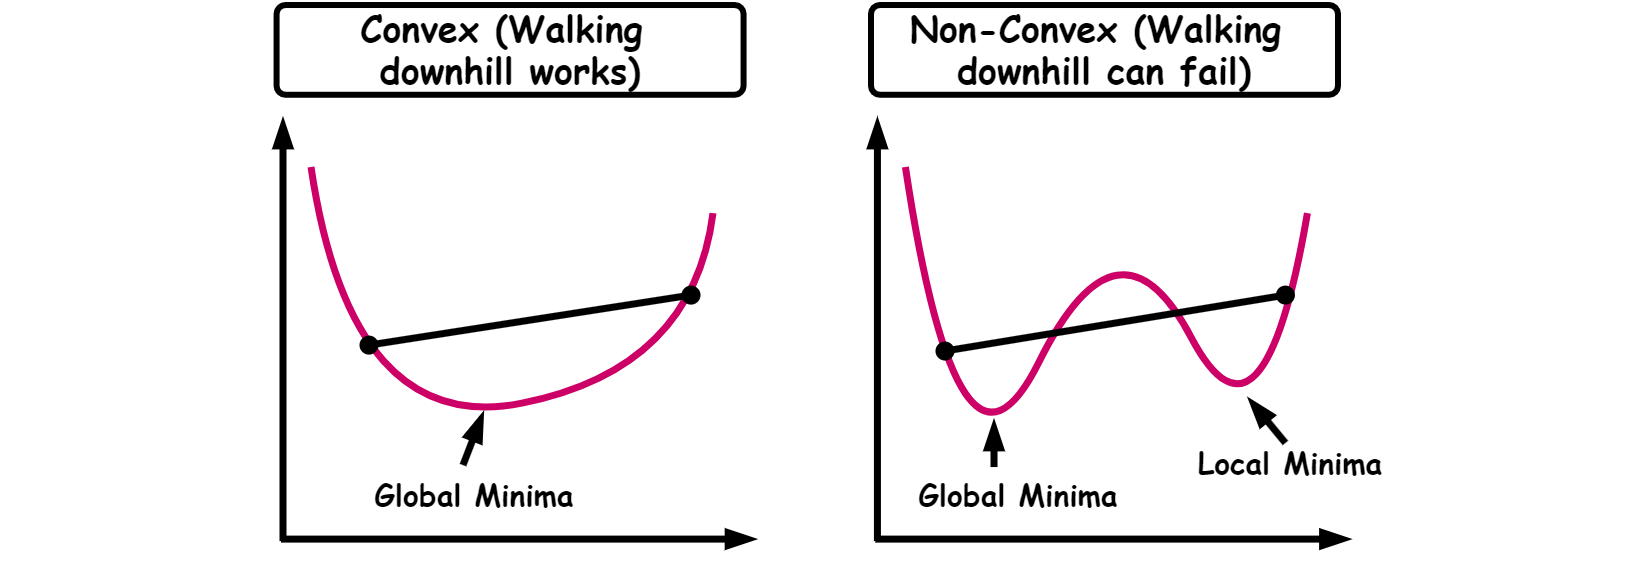

This is why training neural networks requires careful tuning of learning rates, weight initialisation, and optimizers like **Adam** that are designed to escape local minima more reliably than plain gradient descent.

<br>

#### **Vanishing & Exploding Gradients**

Two related problems arise during backpropagation in deep networks:

**Vanishing Gradients** occur when the gradient becomes extremely small as it flows backwards through many layers. Because backpropagation multiplies gradients layer by layer using the chain rule, multiplying many small numbers together produces a near-zero result, meaning the early layers of the network receive almost no learning signal and train extremely slowly or not at all.

**Exploding Gradients** are the opposite, when gradients become very large and accumulate through layers, weight updates become enormous, making training wildly unstable and unusable.

Both problems get worse as networks get deeper, which is one reason why training very deep networks is so much harder than training shallow ones.

<br>

#### **Overfitting & Underfitting**

Even if training converges successfully, the model may still fail to generalise to new, unseen data. There are two ways this can go wrong:

**Overfitting** happens when the model learns the training data too well, including its noise and quirks, and fails to generalise. The model performs great on training data but poorly on new examples.

**Underfitting** happens when the model is too simple or hasn't trained long enough to capture the real patterns in the data. It performs poorly on both training data and new examples.

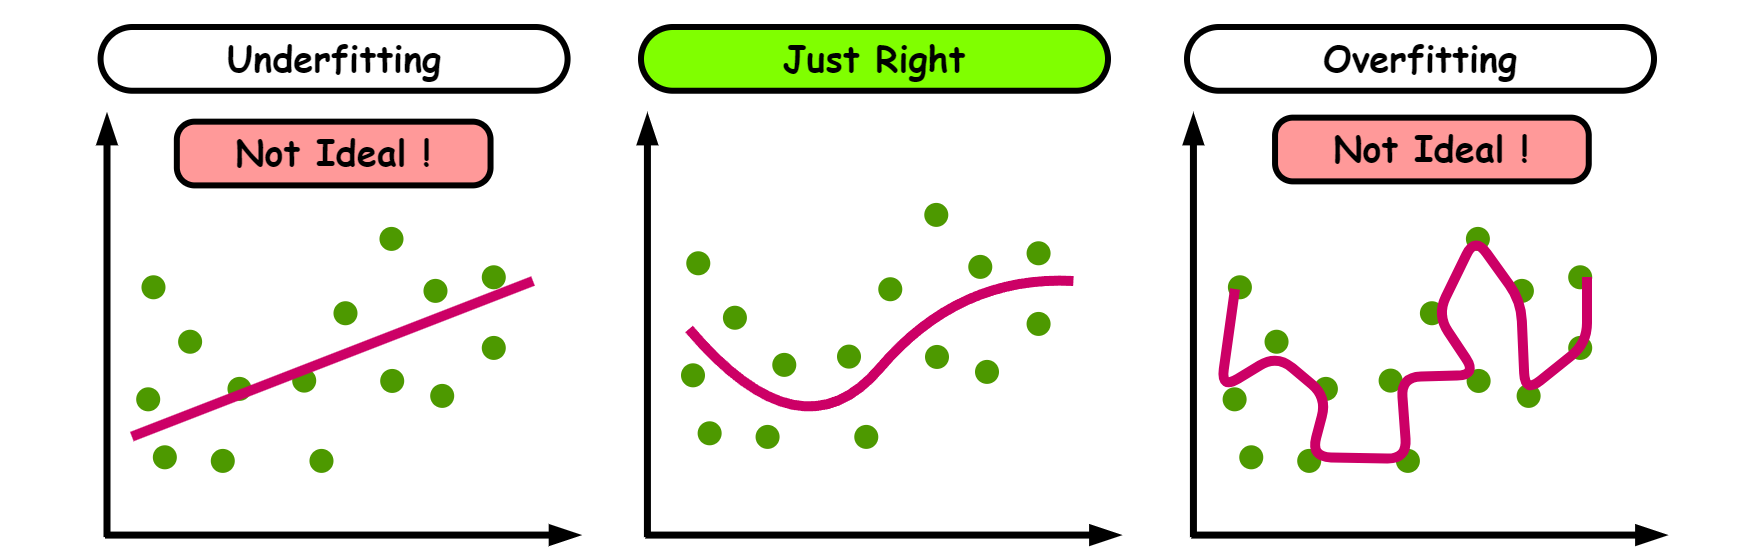

| | Underfitting | Just Right | Overfitting |
|---|---|---|---|
| Training loss | High | Low | Very low |
| Test loss | High | Low | High |
| Cause | Too simple / too few epochs | Good balance | Too complex / too many epochs |
| Fix | More training, more features | — | Early stopping, reduce complexity |

**Early stopping** — halting training before the model fully converges, is one common fix for overfitting. However, stopping too early risks underfitting. The goal is always to find the right balance between the two.

<br>

#### **13.5 Computational Expense**

Neural networks require an enormous number of multiply-and-accumulate operations, every forward and backward pass involves multiplying inputs by weights across every layer for every training example, repeated across hundreds or thousands of epochs. This is measured in **FLOPs** (floating point operations) or **MACs** (multiply-and-accumulate operations).

Because of this, neural networks are almost always trained on **GPUs** rather than CPUs. GPUs are designed to perform thousands of simple arithmetic operations in parallel, making them far better suited to the repetitive matrix multiplications that dominate neural network training.